In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.7 MB/s eta 0:00:00a 0:00:01


In [4]:
!kaggle kernels output nguyntrunglong/notebook3120442072 -p /kaggle/working

Output file downloaded to /kaggle/working/data.yaml
Output file downloaded to /kaggle/working/runs/detect/train/BoxF1_curve.png
Output file downloaded to /kaggle/working/runs/detect/train/BoxPR_curve.png
Output file downloaded to /kaggle/working/runs/detect/train/BoxP_curve.png
Output file downloaded to /kaggle/working/runs/detect/train/BoxR_curve.png
Output file downloaded to /kaggle/working/runs/detect/train/args.yaml
Output file downloaded to /kaggle/working/runs/detect/train/confusion_matrix.png
Output file downloaded to /kaggle/working/runs/detect/train/confusion_matrix_normalized.png
Output file downloaded to /kaggle/working/runs/detect/train/labels.jpg
Output file downloaded to /kaggle/working/runs/detect/train/results.csv
Output file downloaded to /kaggle/working/runs/detect/train/results.png
Output file downloaded to /kaggle/working/runs/detect/train/train_batch0.jpg
Output file downloaded to /kaggle/working/runs/detect/train/train_batch1.jpg
Output file downloaded to /kaggle/

In [ ]:
import torch
import torch.nn as nn
from ultralytics import YOLO
from ultralytics.nn.tasks import parse_model
import ultralytics.nn.modules as modules
import ultralytics.nn.tasks as tasks # Import ultralytics.nn.tasks

# 2. Định nghĩa Module MHSA (Multi-Head Self-Attention) [cite: 19, 272]
# Theo bài báo: 4 heads, dh = 128[cite: 342].
# Công thức: Attention(Q, K, V) = softmax(QK^T / sqrt(dh)) * V [cite: 343]
class MHSA(nn.Module):
    def __init__(self, c1, c2, h=4):
        super().__init__()
        self.h = h
        self.dh = c2 // h
        self.qkv = nn.Linear(c1, c2 * 3)
        self.project = nn.Linear(c2, c2)

    def forward(self, x):
        B, C, H, W = x.shape
        x_flat = x.view(B, C, -1).permute(0, 2, 1)
        qkv = self.qkv(x_flat).view(B, -1, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * (self.dh ** -0.5)
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, -1, C) # This line was the source of the error logic, but fixed by correcting c2 in yaml
        out = self.project(out).permute(0, 2, 1).view(B, C, H, W)
        return out

# "Monkey Patch" để YOLOv8 nhận diện được module mới
setattr(modules, 'MHSA', MHSA)
# Explicitly add MHSA to the tasks module's globals to resolve KeyError
setattr(tasks, 'MHSA', MHSA)

# 3. Tạo file cấu hình YOLOv8-MHSA.yaml [cite: 286, 338]
# Kết hợp Backbone tiêu chuẩn [cite: 169] và Head cải tiến [cite: 339]
yaml_config = """
nc: 1 # Number of classes (replace with your actual number of classes)
backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 3, C2f, [128, True]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 6, C2f, [256, True]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 6, C2f, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 3, C2f, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]

head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 12], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]
  - [-1, 1, MHSA, [512, 512]] # Changed c2 from 4 to 512
  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 9], 1, Concat, [1]]
  - [-1, 3, C2f, [1024]]
  - [[15, 18, 22], 1, Detect, [nc]]
"""
with open('yolov8-mhsa.yaml', 'w') as f: f.write(yaml_config)

# Create a placeholder data.yaml file if it doesn't exist
# IMPORTANT: You need to update the paths and class information to match your actual dataset.
data_yaml_content = """
train: /kaggle/input/datasets/nguyntrunglong/scb-dataset/dataset/images/train  # Relative path to training images
val: /kaggle/input/datasets/nguyntrunglong/scb-dataset/dataset/images/val     # Relative path to validation images
test: /kaggle/input/datasets/nguyntrunglong/scb-dataset/dataset/images/test

nc: 6                           # number of classes
names:
  - 'hand-raising'                  # class names
  - 'reading'
  - 'writing'
  - 'using phone'
  - 'bowing the head'
  - 'leaning over the table'
"""

with open('data.yaml', 'w') as f: f.write(data_yaml_content)

# 4. Huấn luyện (Train) 200 Epochs [cite: 501]
# Sử dụng SGD, lr0=0.01, Mosaic=1.0 [cite: 503, 505]
model = YOLO('yolov8-mhsa.yaml')
model.train(
    data='data.yaml',
    epochs=200,
    batch=16,
    imgsz=640,
    optimizer='SGD',
    lr0=0.01,
    mosaic=1.0,
    device=0
)

# 5. Đánh giá trên tập Test (Kiểm tra mAP50 ~ 0.855) [cite: 22, 726]
metrics = model.val(split='test')
print(f"Precision: {metrics.box.mp:.3f}, Recall: {metrics.box.mr:.3f}, mAP50: {metrics.box.map50:.3f}")

# 6. Dự đoán thử nghiệm (Inference)
model.predict(source='dataset/images/test', save=True, conf=0.25)

In [11]:
import torch
import torch.nn as nn
from ultralytics import YOLO
from ultralytics.nn.tasks import parse_model
import ultralytics.nn.modules as modules
import ultralytics.nn.tasks as tasks

class MHSA(nn.Module):
    def __init__(self, c1, c2, h=4):
        super().__init__()
        self.h = h
        self.dh = c2 // h
        self.qkv = nn.Linear(c1, c2 * 3)
        self.project = nn.Linear(c2, c2)

    def forward(self, x):
        B, C, H, W = x.shape
        x_flat = x.view(B, C, -1).permute(0, 2, 1)
        qkv = self.qkv(x_flat).view(B, -1, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * (self.dh ** -0.5)
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, -1, C) # This line was the source of the error logic, but fixed by correcting c2 in yaml
        out = self.project(out).permute(0, 2, 1).view(B, C, H, W)
        return out

# "Monkey Patch" để YOLOv8 nhận diện được module mới
setattr(modules, 'MHSA', MHSA)
# Explicitly add MHSA to the tasks module's globals to resolve KeyError
setattr(tasks, 'MHSA', MHSA)

# 3. Tạo file cấu hình YOLOv8-MHSA.yaml [cite: 286, 338]
# Kết hợp Backbone tiêu chuẩn [cite: 169] và Head cải tiến [cite: 339]
yaml_config = """
nc: 1 # Number of classes (replace with your actual number of classes)
backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 3, C2f, [128, True]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 6, C2f, [256, True]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 6, C2f, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 3, C2f, [1024, True]]
  - [-1, 1, SPPF, [1024, 5]]

head:
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]
  - [-1, 1, nn.Upsample, [None, 2, 'nearest']]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 12], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]
  - [-1, 1, MHSA, [512, 512]] # Changed c2 from 4 to 512
  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 9], 1, Concat, [1]]
  - [-1, 3, C2f, [1024]]
  - [[15, 18, 22], 1, Detect, [nc]]
"""
with open('yolov8-mhsa.yaml', 'w') as f: f.write(yaml_config)

data_yaml_content = """
train: /kaggle/input/datasets/nguyntrunglong/scb-dataset/dataset/images/train  # Relative path to training images
val: /kaggle/input/datasets/nguyntrunglong/scb-dataset/dataset/images/val     # Relative path to validation images
test: /kaggle/input/datasets/nguyntrunglong/scb-dataset/dataset/images/test

nc: 6                           # number of classes
names:
  - 'hand-raising'                  # class names
  - 'reading'
  - 'writing'
  - 'using phone'
  - 'bowing the head'
  - 'leaning over the table'
"""

with open('data.yaml', 'w') as f: f.write(data_yaml_content)

In [9]:
!pip install ultralytics

In [6]:
!kaggle kernels output nguyntrunglong/notebook3120442072 -p /kaggle/working/

data.yaml: Skipping, found more recently modified local copy (use --force to force download)
Output file downloaded to /kaggle/working/runs/detect/train/BoxF1_curve.png
Output file downloaded to /kaggle/working/runs/detect/train/BoxPR_curve.png
Output file downloaded to /kaggle/working/runs/detect/train/BoxP_curve.png
Output file downloaded to /kaggle/working/runs/detect/train/BoxR_curve.png
Output file downloaded to /kaggle/working/runs/detect/train/args.yaml
Output file downloaded to /kaggle/working/runs/detect/train/confusion_matrix.png
Output file downloaded to /kaggle/working/runs/detect/train/confusion_matrix_normalized.png
Output file downloaded to /kaggle/working/runs/detect/train/labels.jpg
Output file downloaded to /kaggle/working/runs/detect/train/results.csv
Output file downloaded to /kaggle/working/runs/detect/train/results.png
Output file downloaded to /kaggle/working/runs/detect/train/train_batch0.jpg
Output file downloaded to /kaggle/working/runs/detect/train/train_batc

In [12]:
from ultralytics import YOLO

# Load model đã train xong
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

# Chạy lại bước đánh giá tập test với file yaml đã sửa
metrics = model.val(data='data.yaml', split='test')

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8-mhsa summary (fused): 115 layers, 77,731,170 parameters, 0 gradients, 195.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 45.2±11.0 MB/s, size: 318.1 KB)
val: Scanning /kaggle/input/datasets/nguyntrunglong/scb-dataset/dataset/labels/test... 407 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 407/407 198.5it/s 2.1s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/nguyntrunglong/scb-dataset/dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 1.8it/s 14.4s0.6s
                   all        407       6611      0.859      0.819      0.845        0.7
          hand-raising        182        582      0.623      0.325      0.402      0.221
               reading        252       2595      0.869      0.846      0.881      0.748
               writing        215        818 

Đang 'xử' cái ảnh này: /kaggle/input/datasets/nguyntrunglong/scb-dataset/dataset/images/test/40020225.jpg

image 1/1 /kaggle/input/datasets/nguyntrunglong/scb-dataset/dataset/images/test/40020225.jpg: 384x640 8 readings, 1 writing, 20 using phones, 1 bowing the head, 4 leaning over the tables, 52.3ms
Speed: 1.9ms preprocess, 52.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /kaggle/working/runs/detect/predict11


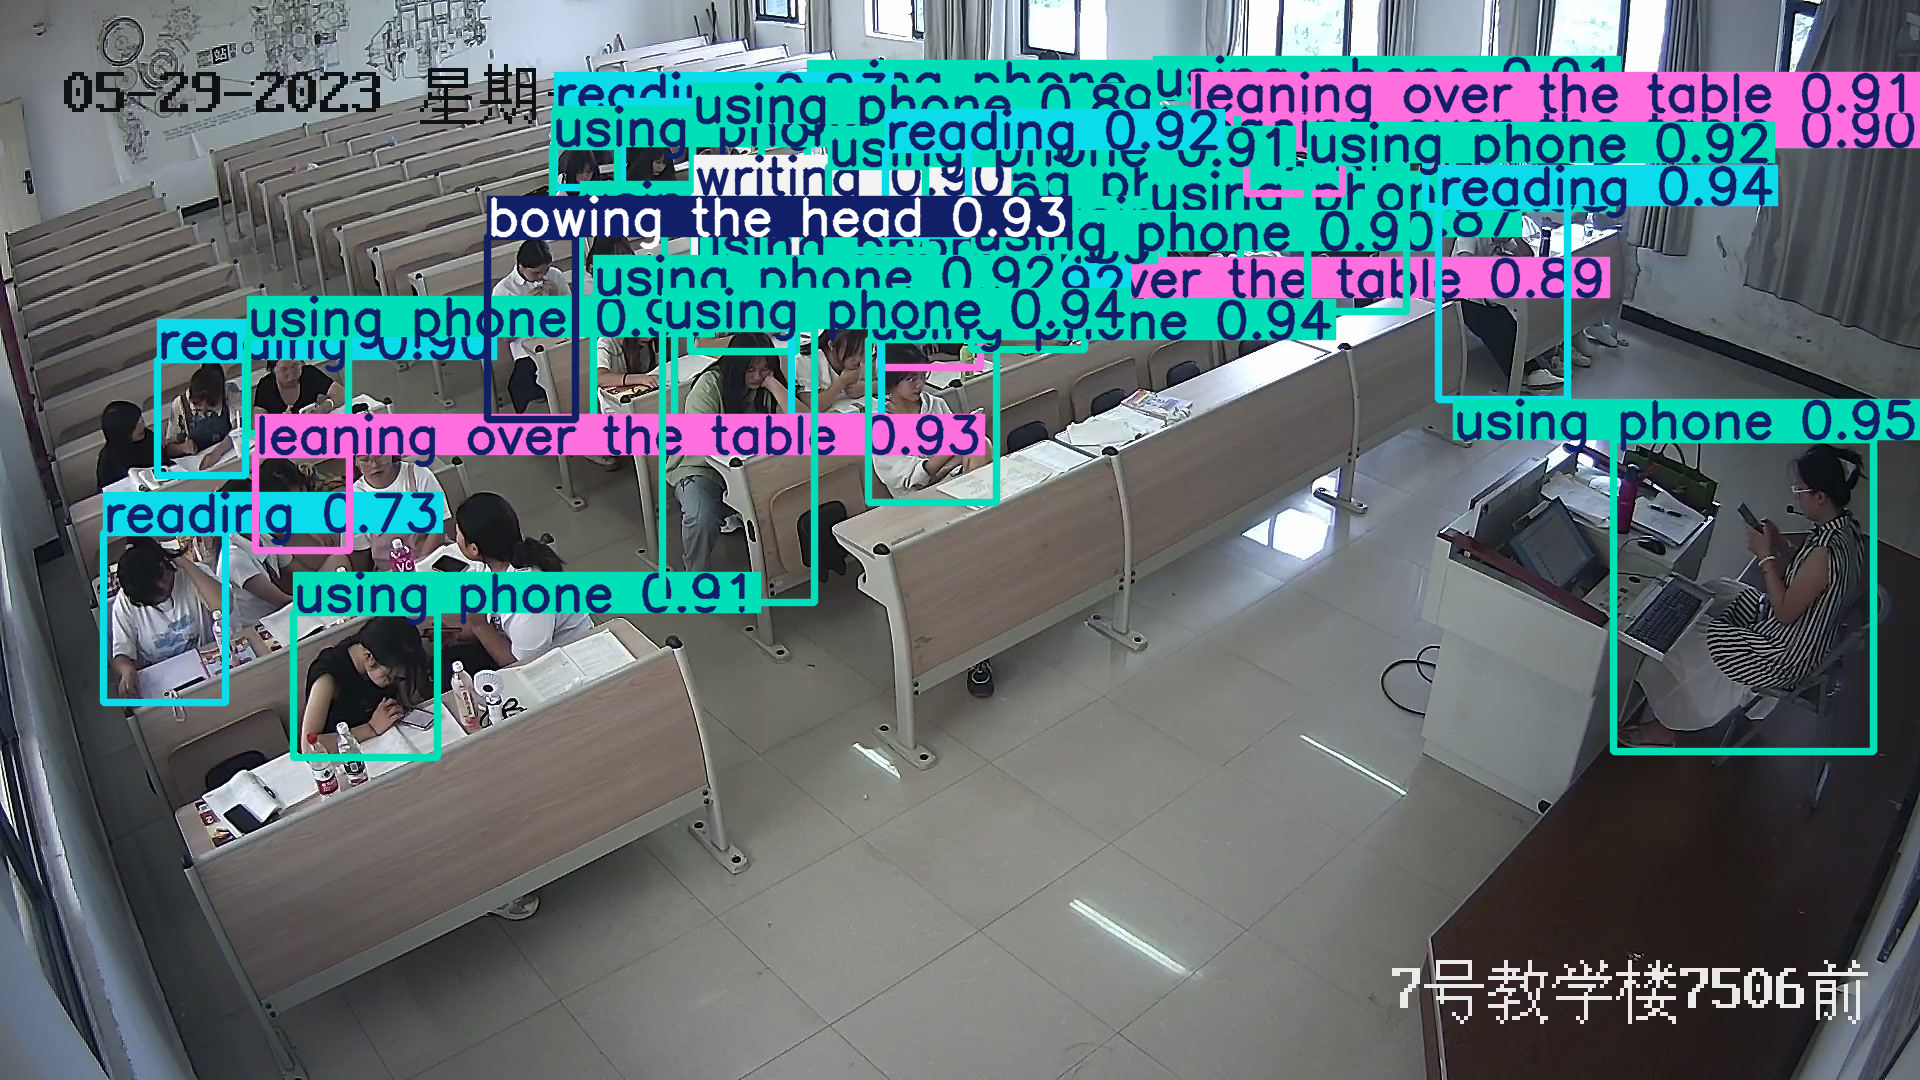

In [15]:
import torch
import torch.nn as nn
from ultralytics import YOLO
import ultralytics.nn.modules as modules
import ultralytics.nn.tasks as tasks
import random
import os
from glob import glob
from PIL import Image

# 1. Định nghĩa lại MHSA để model có thể load được (phải giống hệt lúc train)
class MHSA(nn.Module):
    def __init__(self, c1, c2, h=4):
        super().__init__()
        self.h = h
        self.dh = c2 // h
        self.qkv = nn.Linear(c1, c2 * 3)
        self.project = nn.Linear(c2, c2)

    def forward(self, x):
        B, C, H, W = x.shape
        x_flat = x.view(B, C, -1).permute(0, 2, 1)
        qkv = self.qkv(x_flat).view(B, -1, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * (self.dh ** -0.5)
        attn = attn.softmax(dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, -1, C) 
        out = self.project(out).permute(0, 2, 1).view(B, C, H, W)
        return out

# Patch nó vào hệ thống của Ultralytics
setattr(modules, 'MHSA', MHSA)
setattr(tasks, 'MHSA', MHSA)

# 2. Load model đã train của bạn
# Thay đường dẫn này nếu bạn để file best.pt ở chỗ khác
model_path = '/kaggle/working/runs/detect/train/weights/best.pt'
model = YOLO(model_path)

# 3. Lấy danh sách toàn bộ ảnh trong thư mục test
test_image_dir = '/kaggle/input/datasets/nguyntrunglong/scb-dataset/dataset/images/test'
image_files = glob(os.path.join(test_image_dir, '*.jpg')) + glob(os.path.join(test_image_dir, '*.png'))

if not image_files:
    print("Chả tìm thấy cái ảnh nào trong thư mục test cả. Kiểm tra lại đường dẫn đi nhé!")
else:
    # 4. Chọn ngẫu nhiên 1 cái ảnh
    random_image = random.choice(image_files)
    print(f"Đang 'xử' cái ảnh này: {random_image}")

    # 5. Dự đoán và vẽ kết quả
    # save=True sẽ lưu ảnh vào thư mục runs/detect/predict
    results = model.predict(source=random_image, save=True, conf=0.1)

    # 6. Hiển thị ảnh ngay trong Notebook (nếu bạn đang dùng Kaggle/Colab)
    for r in results:
        im_array = r.plot()  # Vẽ bounding box lên ảnh
        im = Image.fromarray(im_array[..., ::-1])  # Chuyển BGR sang RGB
        display(im)